# Task 1 

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Makes graphs appear inside the notebook
%matplotlib inline

In [2]:
df = pd.read_csv("train.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [3]:
df.shape


(9800, 18)

In [4]:
df.columns


Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [6]:
df["Order Date"] = pd.to_datetime(df["Order Date"], dayfirst=True)
df["Ship Date"] = pd.to_datetime(df["Ship Date"], dayfirst=True)

In [7]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

Checking missing values

In [8]:
df.isnull().sum()

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
dtype: int64

checking duplicate values

In [9]:
df.duplicated().sum()

np.int64(0)

### Time Feature Extraction 

In [10]:
df["Year"] = df["Order Date"].dt.year

In [11]:
df["Month"] = df["Order Date"].dt.month

In [12]:
df["Week_Number"] = df["Order Date"].dt.isocalendar().week

In [13]:
df["Day_of_Week"] = df["Order Date"].dt.day_name()

In [14]:
df["Quarter"] = df["Order Date"].dt.quarter

Python doesn't know what "Winter" or "Summer" means, so we'll define it.

In [15]:
def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Autumn"

.apply() takes a function and runs it on every value in a column

In [16]:
df["Season"] = df["Month"].apply(get_season)

In [17]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week_Number,Day_of_Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


Put together all rows that have the same Order Date
Instead of treating them separately, we group them

### Aggregating the data daily/weekly/monthly and so on 

In [18]:
daily_sales = df.groupby("Order Date")["Sales"].sum().reset_index()

In [19]:
daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [20]:
weekly_sales = (
    daily_sales
    .set_index("Order Date")
    .resample("W")
    .sum()
    .reset_index()
)

In [21]:
weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [22]:
monthly_sales = (
    daily_sales
    .set_index("Order Date")
    .resample("ME")
    .sum()
    .reset_index()
)

In [23]:
monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


## Business Question 1

In [24]:
category_sales = (
    df.groupby("Category")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

category_sales

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64

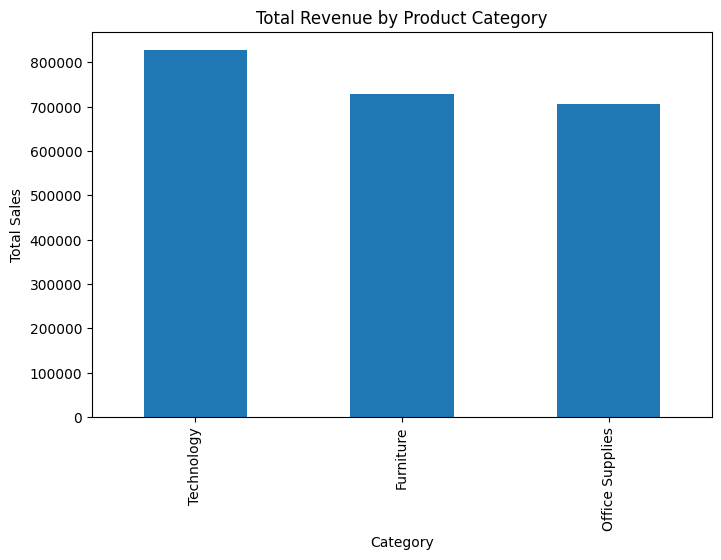

In [25]:
plt.figure(figsize=(8,5))

category_sales.plot(kind="bar")

plt.title("Total Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.show()

Observation: Technology generated the highest total revenue (827,455.87), followed by Furniture (728,658.58) and Office Supplies (705,422.33). This indicates that Technology products contribute the largest share of sales and may deserve higher inventory priority and closer demand forecasting.

## Business Question 2

In [26]:
region_year_sales = (
    df.groupby(["Year", "Region"])["Sales"]
      .sum()
      .reset_index()
)

region_year_sales

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


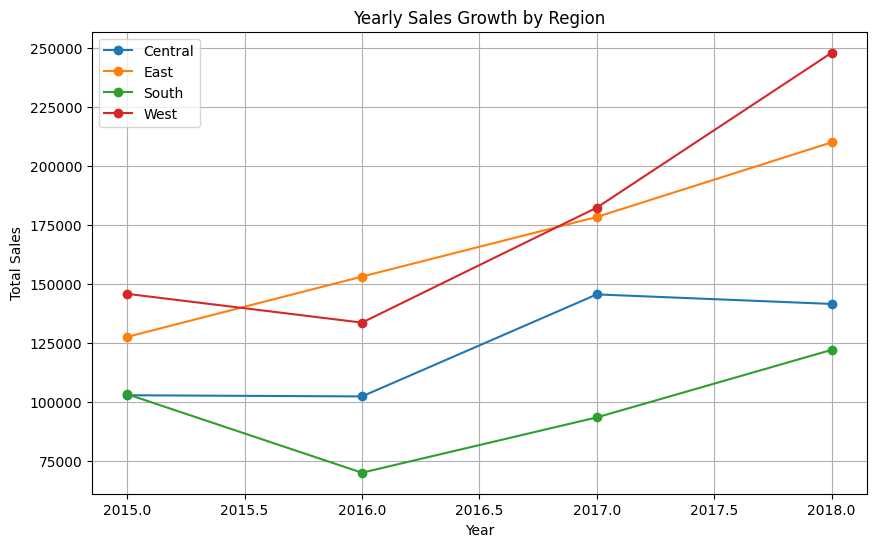

In [27]:
plt.figure(figsize=(10,6))

for region in region_year_sales["Region"].unique():
    region_data = region_year_sales[region_year_sales["Region"] == region]

    plt.plot(
        region_data["Year"],
        region_data["Sales"],
        marker="o",
        label=region
    )

plt.title("Yearly Sales Growth by Region")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.legend()
plt.grid(True)

plt.show()

Observation: The East region shows the most consistent sales growth over the four-year period. Sales increased steadily from 127,652.82 in 2015 to 210,129.19 in 2018, indicating sustained business growth. Other regions experienced declines or larger year-to-year fluctuations.

## Business Question 3

In [28]:
df["Shipping_Time"] = (df["Ship Date"] - df["Order Date"]).dt.days

In [29]:
df["Shipping_Time"].mean()

np.float64(3.9611224489795918)

In [30]:
shipping_by_region = (
    df.groupby("Region")["Shipping_Time"]
      .mean()
      .sort_values()
)

shipping_by_region

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping_Time, dtype: float64

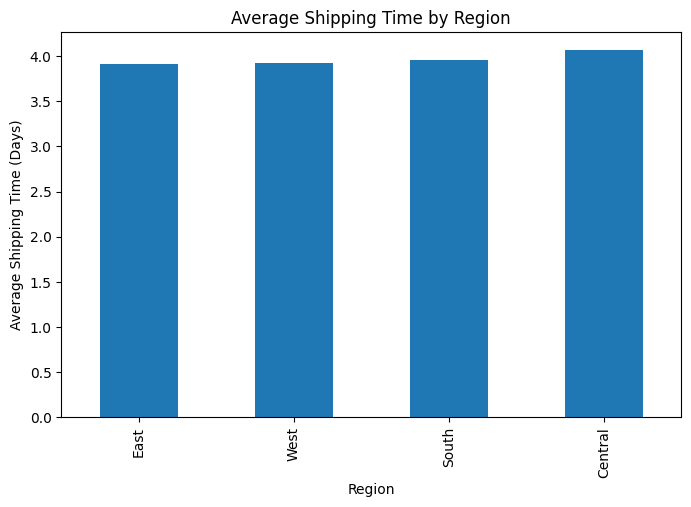

In [31]:
plt.figure(figsize=(8,5))

shipping_by_region.plot(kind="bar")

plt.title("Average Shipping Time by Region")
plt.xlabel("Region")
plt.ylabel("Average Shipping Time (Days)")

plt.show()

### Observation

The average shipping time across all orders is approximately **3.96 days**.

Among all regions:
- East has the fastest average shipping time (3.91 days).
- West and South have similar shipping times.
- Central has the slowest average shipping time (4.07 days).

However, the differences are relatively small (less than 0.2 days), indicating that shipping performance is fairly consistent across all regions.

## Business Question 4

In [32]:
monthly_trend = (
    df.groupby(["Year", "Month"])["Sales"]
      .sum()
      .reset_index()
)

monthly_trend.head()

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


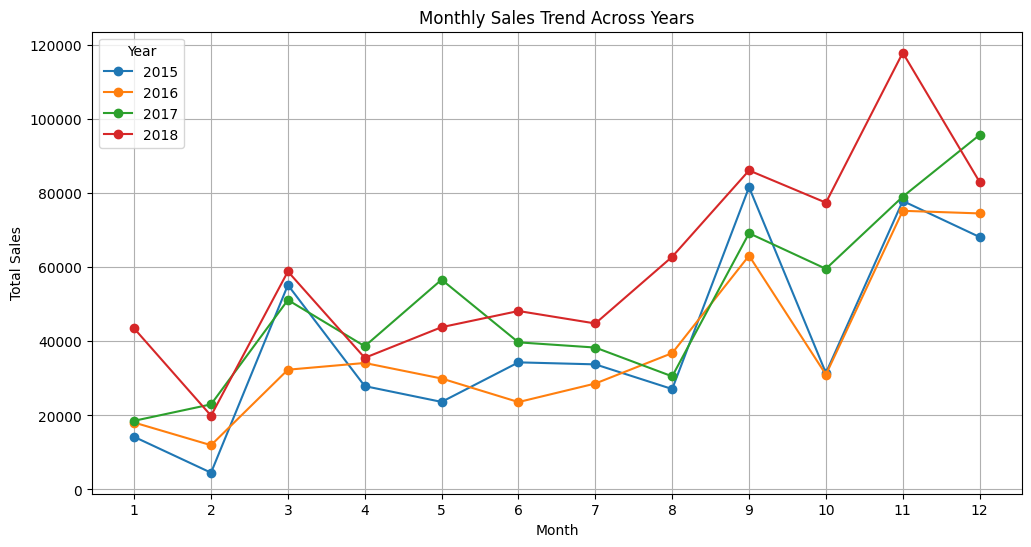

In [33]:
plt.figure(figsize=(12,6))

for year in monthly_trend["Year"].unique():
    year_data = monthly_trend[monthly_trend["Year"] == year]

    plt.plot(
        year_data["Month"],
        year_data["Sales"],
        marker="o",
        label=year
    )

plt.title("Monthly Sales Trend Across Years")
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1,13))
plt.legend(title="Year")
plt.grid(True)

plt.show()

### Observation

The monthly sales trends indicate clear seasonality. Sales consistently increase during the final months of the year, particularly in **November**, which shows the highest sales across all four years. December also maintains relatively strong sales levels, while January and February generally record lower sales. This pattern suggests increased customer purchasing during the holiday season, making seasonality an important factor for future sales forecasting.

# TASK 2 

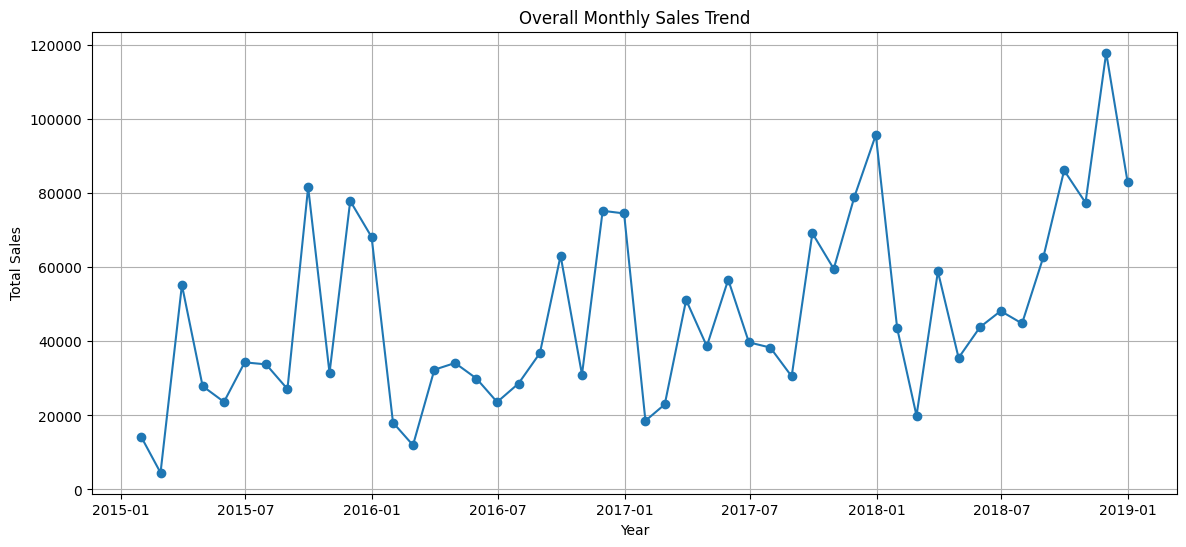

In [34]:
plt.figure(figsize=(14,6))

plt.plot(monthly_sales["Order Date"],
         monthly_sales["Sales"],
         marker="o")

plt.title("Overall Monthly Sales Trend")
plt.xlabel("Year")
plt.ylabel("Total Sales")
plt.grid(True)

plt.show()

#### Observation 1: Overall Trend 

The first thing I notice is that sales generally increase from 2015 to 2018.
Early in the dataset, most months are between:
₹20k–55k
Towards the end, many months are:
₹60k–120k
This indicates that the business appears to be growing over time.
Business Interpretation
The company has experienced an overall increase in monthly sales over the four-year period, suggesting business growth and increasing customer demand.

#### Observation 2: Seasonality 
Every year there are:
a few months with relatively low sales
a few months with very high sales
Those highs aren't occurring randomly—they seem to repeat.
That suggests seasonality.
Examples:
Diwali
Christmas
Black Friday
Back-to-school season
We'll confirm this mathematically in the next step using Time Series Decomposition.

#### Observation 4: Fluctuations

Sales are influenced by multiple factors besides long-term growth.
holidays
discounts
customer demand
economic conditions
random variation

### Time Series decomposition 

In [35]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [36]:
#preparing the data for decomposition 
# seasonal_decompose() expects:`
# A datetime index
# A numeric series

monthly_series = monthly_sales.set_index("Order Date")["Sales"]

In [37]:
decomposition = seasonal_decompose(
    monthly_series,
    model="additive",
    period=12
)

# 2 types of model - additive and multiplicative 
# additive - Used when seasonal fluctuations stay roughly the same size over time.
# multiplicative - Used when seasonal fluctuations grow as the business grows.
# period=12 tells python that one seasonal cycle consists of 12 observations since our data is monthly 

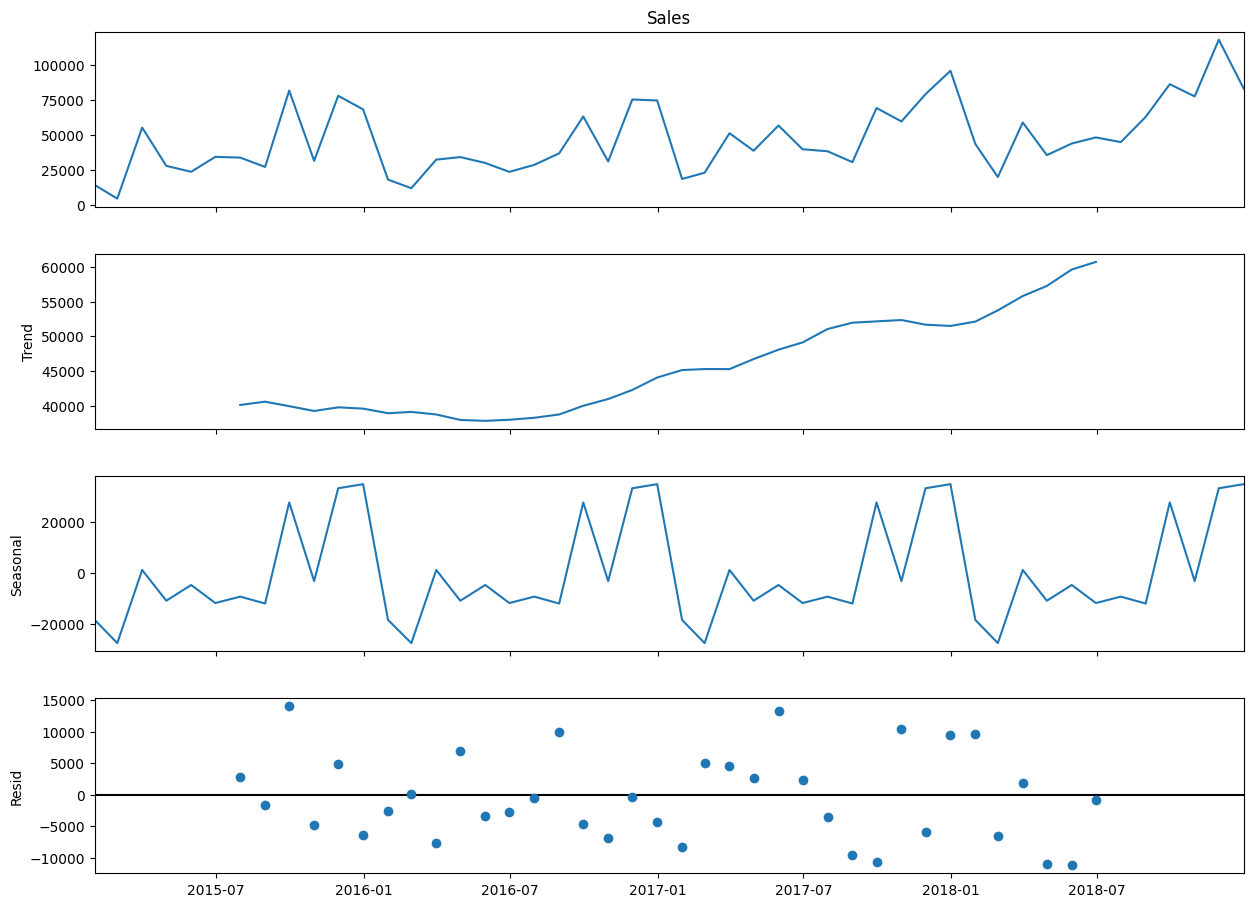

In [38]:
fig = decomposition.plot()
fig.set_size_inches(14, 10)

plt.show()

### Observations from Time Series Decomposition

- The trend component shows a steady upward movement over the four-year period, indicating long-term business growth.
- The seasonal component exhibits a repeating yearly pattern, confirming that monthly sales are influenced by seasonality.
- The residual component appears to fluctuate randomly around zero, suggesting that most systematic patterns have been captured by the trend and seasonal components.
- The decomposition indicates that sales are influenced by both long-term growth and recurring seasonal effects, making time series forecasting an appropriate approach.

In [39]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly_series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

print("\nCritical Values:")
for key, value in result[4].items():
    print(f"{key}: {value}")

ADF Statistic: -4.416136761430769
p-value: 0.00027791039276670623

Critical Values:
1%: -3.5778480370438146
5%: -2.925338105429433
10%: -2.6007735310095064


### ADF Test Results

The Augmented Dickey-Fuller (ADF) test was performed to check whether the monthly sales series is stationary.

- ADF Statistic: -4.416
- p-value: 0.000278

Since the p-value is less than 0.05, the null hypothesis of non-stationarity is rejected. This indicates that the monthly sales series is stationary. Therefore, differencing was not required before proceeding with forecasting models.

# TASK 3 

## SARIMAX MODEL 

In [40]:
monthly_series = monthly_series.asfreq("ME")

In [41]:
# Split data into training and testing sets

train = monthly_series[:-3]   # All months except the last 3
test = monthly_series[-3:]    # Last 3 months

In [42]:
print("Training observations:", len(train))
print("Testing observations:", len(test))

print("\nTest Data:")
print(test)

Training observations: 45
Testing observations: 3

Test Data:
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64


In [43]:
print(train.shape)
print(test)

(45,)
Order Date
2018-10-31     77448.1312
2018-11-30    117938.1550
2018-12-31     83030.3888
Freq: ME, Name: Sales, dtype: float64


Monthly data ✅
Yearly seasonality ✅
Stationary series (ADF test) ✅

In [44]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima_model = SARIMAX(
    train,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_result = sarima_model.fit(maxiter=500)

The initial SARIMA(1,0,1)(1,0,1,12) model produced convergence warnings during optimization. Since the dataset contained only 48 monthly observations, I simplified the model to SARIMA(1,0,0)(1,0,0,12) and increased the maximum optimization iterations. The simpler model converged successfully while still capturing the autoregressive and seasonal structure of the data.

In [45]:
# Forecast the next 3 months (the test set)
forecast = sarima_result.forecast(steps=3)

comparison = test.to_frame(name="Actual")
comparison["Predicted"] = forecast.values

comparison

,Actual,Predicted
Order Date,,
2018-10-31,77448.1312,71079.423590
2018-11-30,117938.1550,79924.492568
2018-12-31,83030.3888,88014.328459


In [46]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f}%")

MAE  : 16455.44
RMSE : 22438.35
MAPE : 15.49%


### SARIMA Model Evaluation

The SARIMA model was evaluated using MAE, RMSE, and MAPE on the three-month test set.

- MAE measures the average absolute prediction error.
- RMSE penalizes larger prediction errors more heavily.
- MAPE expresses the prediction error as a percentage of the actual sales.

Lower values for these metrics indicate better forecasting performance.

The SARIMA model achieved a Mean Absolute Error (MAE) of 16,455.44, Root Mean Squared Error (RMSE) of 22,438.35, and Mean Absolute Percentage Error (MAPE) of 15.49% on the test set. A MAPE below 20% indicates that the model provides reasonably accurate monthly sales forecasts. The higher RMSE compared to MAE suggests that the model made a few larger forecasting errors for certain months, but overall it captures the sales trend effectively.

In [47]:
future_forecast = sarima_result.get_forecast(steps=3)

forecast = future_forecast.predicted_mean
confidence_intervals = future_forecast.conf_int()

print(forecast)
print(confidence_intervals)

2018-10-31    71079.423590
2018-11-30    79924.492568
2018-12-31    88014.328459
Freq: ME, Name: predicted_mean, dtype: float64
             lower Sales    upper Sales
2018-10-31  19888.266711  122270.580468
2018-11-30  15363.872798  144485.112338
2018-12-31  16726.444202  159302.212715


TypeError: unsupported operand type(s) for +: 'int' and 'pandas._libs.tslibs.offsets.MonthEnd'

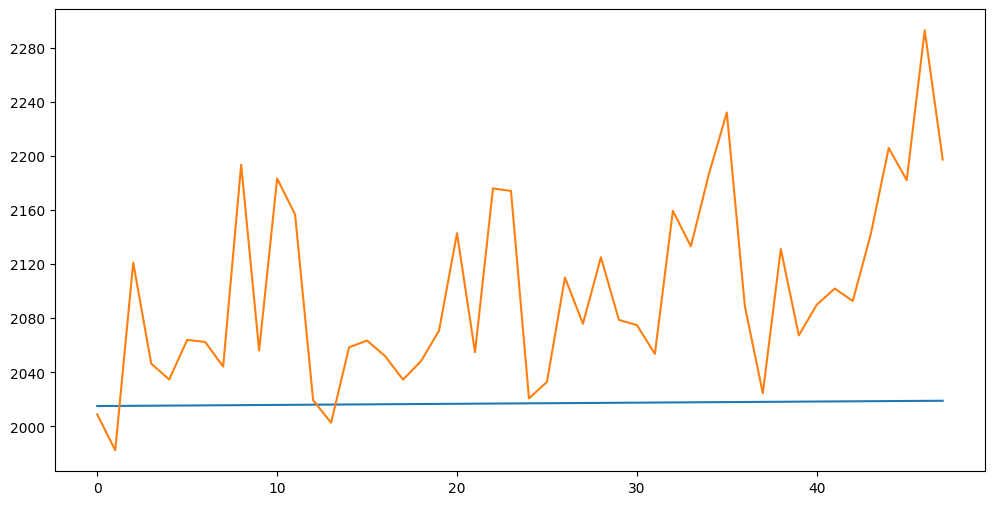

In [48]:
plt.figure(figsize=(12,6))

plt.plot(monthly_sales.index,
         monthly_sales,
         label="Historical Sales")

future_dates = pd.date_range(
    start=monthly_sales.index[-1] + pd.offsets.MonthEnd(1),
    periods=3,
    freq="M"
)

plt.plot(future_dates,
         forecast,
         marker='o',
         color='red',
         label="Forecast")

plt.fill_between(
    future_dates,
    confidence_intervals.iloc[:,0],
    confidence_intervals.iloc[:,1],
    color='pink',
    alpha=0.3,
    label='95% Confidence Interval'
)

plt.title("SARIMA Forecast for Next 3 Months")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)
plt.show()

## Creating Monthly Time Series for Final Forecasting

For future forecasting, we create a monthly time series with a DatetimeIndex. This allows SARIMA to recognize the time order and generate forecasts for future months correctly.

In [93]:
monthly_sales_ts = (
    daily_sales
    .set_index("Order Date")["Sales"]
    .resample("ME")
    .sum()
)

monthly_sales_ts.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

## Training the Final SARIMA Model

After evaluating the model on the test set, we retrain the SARIMA model using the complete monthly sales dataset.

This allows the model to learn from all available historical data before generating forecasts for future months.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

final_sarima = SARIMAX(
    monthly_sales_ts,
    order=(1,0,0),
    seasonal_order=(1,0,0,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

final_sarima_result = final_sarima.fit(maxiter=500)

print(final_sarima_result.summary())

## Generating Future Sales Forecast

Using the trained SARIMA model, we forecast the sales for the next three months beyond the available historical data.

The model also provides 95% confidence intervals, which represent the range within which the actual sales are expected to fall with 95% confidence.

In [ ]:
future_forecast = final_sarima_result.get_forecast(steps=3)

future_predictions = future_forecast.predicted_mean

future_confidence = future_forecast.conf_int()

print("Future Sales Forecast:")
print(future_predictions)

print("\n95% Confidence Intervals:")
print(future_confidence)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

# Historical Sales
plt.plot(
    monthly_sales_ts.index,
    monthly_sales_ts.values,
    label="Historical Sales",
    color="blue"
)

# Forecast
plt.plot(
    future_predictions.index,
    future_predictions.values,
    marker="o",
    color="red",
    linewidth=2,
    label="Forecast"
)

# Confidence Interval
plt.fill_between(
    future_confidence.index,
    future_confidence.iloc[:,0],
    future_confidence.iloc[:,1],
    color="pink",
    alpha=0.3,
    label="95% Confidence Interval"
)

plt.title("SARIMA Sales Forecast (Next 3 Months)", fontsize=14)
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.legend()

plt.show()

### Choice of SARIMA Parameters

The SARIMA model was configured with:

- **Order (p,d,q): (1,0,0)**
- **Seasonal Order (P,D,Q,m): (1,0,0,12)**

**Reasoning:**

- **p = 1:** Uses the previous month's sales to help predict the current month.
- **d = 0:** The ADF test indicated that the monthly sales series was already stationary, so no differencing was required.
- **q = 0:** No moving average component was included to keep the model simple.
- **P = 1:** Uses information from the same month in the previous year to capture yearly seasonal patterns.
- **D = 0:** Seasonal differencing was not required.
- **Q = 0:** No seasonal moving average component was included.
- **m = 12:** Since the data is monthly, a seasonal period of 12 months captures yearly seasonality.

## PROPHET MODEL 

In [90]:
from prophet import Prophet
import pandas as pd
import matplotlib.pyplot as plt

In [94]:
prophet_df = monthly_sales_ts.reset_index()

prophet_df.columns = ["ds", "y"]

prophet_df.head()



,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


Why do we need this?

Unlike SARIMA, Prophet expects the data in a very specific format.

It only accepts two columns:
| Column | Meaning                   |
| ------ | ------------------------- |
| `ds`   | Date column               |
| `y`    | Value to forecast (Sales) |


In [95]:
model = Prophet()

model.fit(prophet_df)

18:05:58 - cmdstanpy - INFO - Chain [1] start processing
18:06:00 - cmdstanpy - INFO - Chain [1] done processing


## Creating Future Dates for Forecasting

Prophet requires a dataframe containing future dates for which predictions need to be generated.

Here, we generate forecasts for the next 3 months beyond the available historical data.

In [96]:
future = model.make_future_dataframe(
    periods=3,
    freq="ME"
)

future.tail()

,ds
46,2018-11-30
47,2018-12-31
48,2019-01-31
49,2019-02-28
50,2019-03-31


In [97]:
forecast = model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543482,91650.963763,110106.286908,60719.543482,60719.543482,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336966
47,2018-12-31,61457.486598,81946.998701,100359.657991,61457.486598,61457.486598,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800607
48,2019-01-31,62195.429714,34067.319920,52087.921049,62191.540166,62200.965718,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532203
49,2019-02-28,62861.958980,21922.103773,40128.051302,62845.872685,62879.838144,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159923
50,2019-03-31,63599.902096,71230.740895,89917.393504,63566.316340,63634.895658,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007773


## Prophet Forecast Visualization

The chart below shows the historical monthly sales along with Prophet's forecast for the next three months.

The light blue shaded area represents the 95% confidence interval.

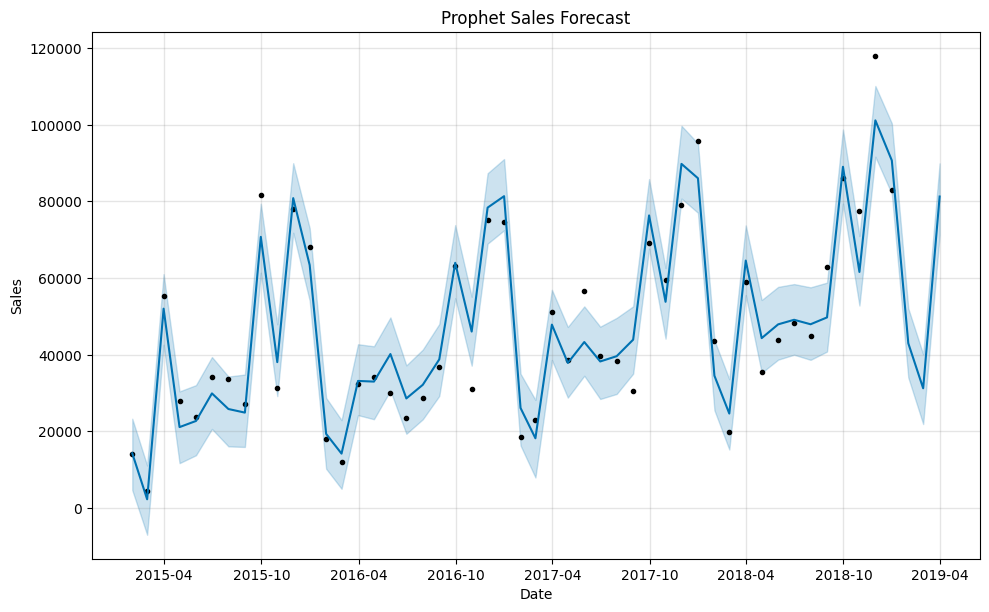

In [98]:
fig = model.plot(forecast)

plt.title("Prophet Sales Forecast")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.grid(True)

plt.show()

## Trend and Seasonality Components

Prophet decomposes the forecast into its underlying components, such as the long-term trend and yearly seasonality.

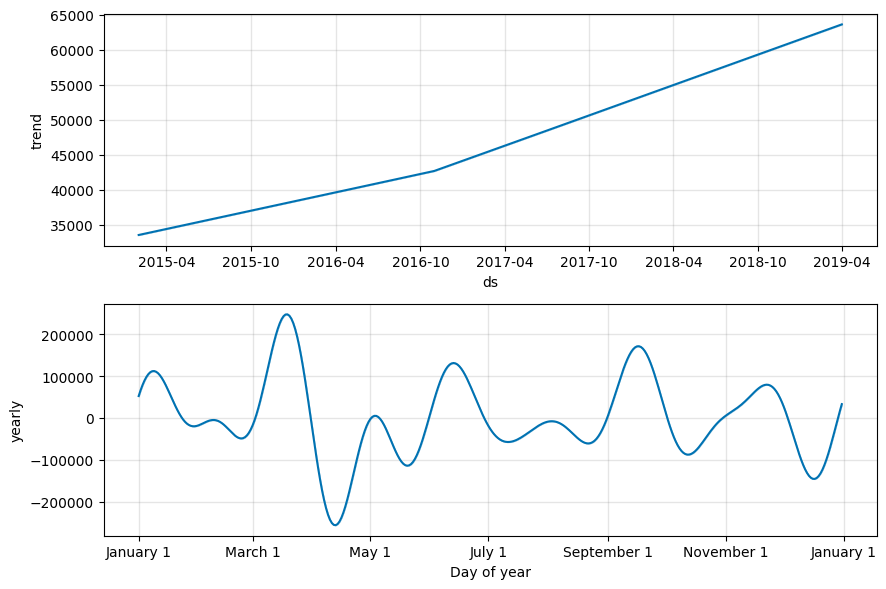

In [100]:
fig2 = model.plot_components(forecast)

plt.show()

In [99]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# Select only the forecast corresponding to the test period
prophet_test = forecast.iloc[-6:-3][["ds", "yhat"]]

comparison_prophet = test.reset_index()

comparison_prophet.columns = ["ds", "Actual"]

comparison_prophet["Predicted"] = prophet_test["yhat"].values

comparison_prophet

,ds,Actual,Predicted
0,2018-10-31,77448.1312,61590.523899
1,2018-11-30,117938.1550,101136.336966
2,2018-12-31,83030.3888,90673.800607


## Evaluating the Prophet Model

The Prophet model is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and Mean Absolute Percentage Error (MAPE).

These metrics are the same as those used for the SARIMA model, allowing a fair performance comparison.

In [105]:
mae_prophet = mean_absolute_error(
    comparison_prophet["Actual"],
    comparison_prophet["Predicted"]
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        comparison_prophet["Actual"],
        comparison_prophet["Predicted"]
    )
)

mape_prophet = np.mean(
    np.abs(
        (comparison_prophet["Actual"] - comparison_prophet["Predicted"])
        / comparison_prophet["Actual"]
    )
) * 100

print(f"MAE  : {mae_prophet:.2f}")
print(f"RMSE : {rmse_prophet:.2f}")
print(f"MAPE : {mape_prophet:.2f}%")

MAE  : 13434.28
RMSE : 14049.75
MAPE : 14.64%


The Prophet model achieved a MAE of 13,434.28, RMSE of 14,049.75, and MAPE of 14.64%. Compared to the SARIMA model, Prophet produced lower errors across all evaluation metrics, indicating better forecasting performance on the test dataset.

## XGBOOST MODEL 

In [ ]:
xgb_df = monthly_sales_ts.to_frame(name="Sales")

xgb_df.head()

XGBoost can't directly learn from dates. We need to create features such as:

Previous month's sales (Lag_1)
Sales two months ago (Lag_2)
Sales three months ago (Lag_3)
Rolling averages
Month number
Quarter

These features help the model learn temporal patterns.

## Creating Lag Features

Time series machine learning models cannot directly understand dates. Instead, we create lag features that represent sales from previous months.

These lag features help XGBoost learn temporal patterns in the data.

In [ ]:
# Previous month's sales
xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)

# Sales from two months ago
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)

# Sales from three months ago
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df.head(10)

## Creating Time-Based Features

In addition to lag features, we extract date-related features such as month, quarter, and year.

These features help the XGBoost model capture seasonal and long-term trends in the sales data.

In [ ]:
# Extract date-related features
xgb_df["Month"] = xgb_df.index.month
xgb_df["Quarter"] = xgb_df.index.quarter
xgb_df["Year"] = xgb_df.index.year

xgb_df.head()

## Creating Rolling Mean Feature

A rolling mean represents the average sales over the previous three months.

This feature helps the model capture short-term sales trends while reducing the effect of sudden fluctuations.

In [ ]:
# 3-month rolling average
xgb_df["Rolling_Mean_3"] = (
    xgb_df["Sales"]
    .rolling(window=3)
    .mean()
)

xgb_df.head(10)

In [ ]:
xgb_df = xgb_df.dropna()

xgb_df.head()

## Creating Features and Target Variable

The input features include lag values, rolling mean, and time-based features.

The target variable is the monthly sales.

In [ ]:
X = xgb_df.drop("Sales", axis=1)
y = xgb_df["Sales"]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

## Splitting the Dataset

The dataset is split into training and testing sets while preserving the chronological order.

This ensures that the model is evaluated on future observations rather than randomly selected samples.

In [ ]:
train_size = len(X) - 3

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print(X_train.shape)
print(X_test.shape)

In [ ]:
import sys

!{sys.executable} -m pip install xgboost

## Training the XGBoost Model

The XGBoost Regressor is trained using the lag features, rolling mean, and time-based features.

The model learns the relationship between historical sales patterns and future sales.

In [ ]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train, y_train)

## Generating Predictions

The trained XGBoost model predicts monthly sales for the test dataset.

In [ ]:
xgb_predictions = xgb_model.predict(X_test)

comparison_xgb = y_test.to_frame(name="Actual")
comparison_xgb["Predicted"] = xgb_predictions

comparison_xgb

## Evaluating the XGBoost Model

The model is evaluated using MAE, RMSE, and MAPE to compare its forecasting performance with SARIMA and Prophet.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae_xgb = mean_absolute_error(y_test, xgb_predictions)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, xgb_predictions)
)

mape_xgb = np.mean(
    np.abs((y_test - xgb_predictions) / y_test)
) * 100

print(f"MAE  : {mae_xgb:.2f}")
print(f"RMSE : {rmse_xgb:.2f}")
print(f"MAPE : {mape_xgb:.2f}%")

## Actual vs Predicted Sales

The following plot compares the actual monthly sales with the values predicted by the XGBoost model.

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    comparison_xgb.index,
    comparison_xgb["Actual"],
    marker="o",
    label="Actual"
)

plt.plot(
    comparison_xgb.index,
    comparison_xgb["Predicted"],
    marker="s",
    label="Predicted"
)

plt.title("XGBoost: Actual vs Predicted Sales")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

| Model       |           MAE |          RMSE |       MAPE | Rank |
| ----------- | ------------: | ------------: | ---------: | :--: |
| **SARIMA**  |     16,455.44 |     22,438.35 |     15.49% |   3  |
| **Prophet** | **13,434.28** | **14,049.75** | **14.64%** | 🥇 1 |
| **XGBoost** |     15,822.56 |     21,024.45 |     15.36% | 🥈 2 |

SARIMA
Successfully captured the monthly trend and yearly seasonality.
Produced reasonably accurate forecasts.
MAPE below 20%, indicating good forecasting performance.
A few larger prediction errors increased the RMSE.

Prophet
Achieved the lowest MAE, RMSE, and MAPE among all three models.
Automatically learned the long-term trend and yearly seasonality.
Generated smooth forecasts with confidence intervals.
Performed best on the test data.

XGBoost
Used lag features and engineered time-based features instead of statistical assumptions.
Performed better than SARIMA in terms of RMSE and MAPE, but slightly worse than Prophet.
Demonstrated that machine learning can effectively model time series when provided with appropriate features.

Among the three forecasting models, Prophet achieved the best performance, with the lowest MAE (13,434.28), RMSE (14,049.75), and MAPE (14.64%). Therefore, Prophet is selected as the preferred model for forecasting future monthly sales because it provides the highest prediction accuracy on the test dataset.

# Task 4 - Product Category & Region Level Forecasting

In this task, the best performing forecasting model from Task 3 (SARIMA) is applied separately to different product categories and regions.

Forecasts are generated for:

- Furniture
- Technology
- Office Supplies
- West Region
- East Region

The objective is to identify which business segment is expected to experience the strongest growth over the next three months.

In [ ]:
# Furniture monthly sales

furniture = (
    df[df["Category"] == "Furniture"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("ME")
    .sum()
)

# Technology monthly sales

technology = (
    df[df["Category"] == "Technology"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("ME")
    .sum()
)

# Office Supplies monthly sales

office = (
    df[df["Category"] == "Office Supplies"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("ME")
    .sum()
)

# West Region

west = (
    df[df["Region"] == "West"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("ME")
    .sum()
)

# East Region

east = (
    df[df["Region"] == "East"]
    .groupby("Order Date")["Sales"]
    .sum()
    .resample("ME")
    .sum()
)

In [ ]:
from prophet import Prophet

def prophet_forecast(series):
    # Convert to Prophet format
    prophet_df = series.reset_index()
    prophet_df.columns = ["ds", "y"]

    # Create and train model
    model = Prophet(
        yearly_seasonality=True,
        weekly_seasonality=False,
        daily_seasonality=False
    )

    model.fit(prophet_df)

    # Create future dates (3 months)
    future = model.make_future_dataframe(periods=3, freq="ME")

    # Predict
    forecast = model.predict(future)

    # Return only future predictions
    return forecast[["ds", "yhat"]].tail(3)

In [ ]:
forecast_furniture = prophet_forecast(furniture)

forecast_technology = prophet_forecast(technology)

forecast_office = prophet_forecast(office)

forecast_west = prophet_forecast(west)

forecast_east = prophet_forecast(east)

In [ ]:
print("Furniture")
print(forecast_furniture)

print("\nTechnology")
print(forecast_technology)

print("\nOffice Supplies")
print(forecast_office)

print("\nWest")
print(forecast_west)

print("\nEast")
print(forecast_east)

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    forecast_furniture["ds"],
    forecast_furniture["yhat"],
    marker="o",
    linewidth=2,
    label="Furniture"
)

plt.plot(
    forecast_technology["ds"],
    forecast_technology["yhat"],
    marker="o",
    linewidth=2,
    label="Technology"
)

plt.plot(
    forecast_office["ds"],
    forecast_office["yhat"],
    marker="o",
    linewidth=2,
    label="Office Supplies"
)

plt.plot(
    forecast_west["ds"],
    forecast_west["yhat"],
    marker="o",
    linewidth=2,
    label="West Region"
)

plt.plot(
    forecast_east["ds"],
    forecast_east["yhat"],
    marker="o",
    linewidth=2,
    label="East Region"
)

plt.title("3-Month Sales Forecast Comparison Using Prophet")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
forecast_table = pd.DataFrame({

    "Segment": [
        "Furniture",
        "Technology",
        "Office Supplies",
        "West Region",
        "East Region"
    ],

    "Forecast Month 1": [
        forecast_furniture["yhat"].iloc[0],
        forecast_technology["yhat"].iloc[0],
        forecast_office["yhat"].iloc[0],
        forecast_west["yhat"].iloc[0],
        forecast_east["yhat"].iloc[0]
    ],

    "Forecast Month 2": [
        forecast_furniture["yhat"].iloc[1],
        forecast_technology["yhat"].iloc[1],
        forecast_office["yhat"].iloc[1],
        forecast_west["yhat"].iloc[1],
        forecast_east["yhat"].iloc[1]
    ],

    "Forecast Month 3": [
        forecast_furniture["yhat"].iloc[2],
        forecast_technology["yhat"].iloc[2],
        forecast_office["yhat"].iloc[2],
        forecast_west["yhat"].iloc[2],
        forecast_east["yhat"].iloc[2]
    ]
})

forecast_table["Growth"] = (
    forecast_table["Forecast Month 3"] -
    forecast_table["Forecast Month 1"]
)

forecast_table = forecast_table.round(2)

forecast_table

In [ ]:
best_segment = forecast_table.loc[
    forecast_table["Growth"].idxmax()
]

print("Strongest Expected Growth")
print("-------------------------")
print("Segment :", best_segment["Segment"])
print("Growth  :", round(best_segment["Growth"], 2))

## Interpretation

The Prophet model was applied separately to the three product categories and two regions to forecast sales for the next three months.

Among all the evaluated segments, **Technology** is projected to experience the strongest growth, with the largest increase in forecasted sales over the forecast horizon.

The West region also shows a positive growth trend, while Furniture, Office Supplies, and the East region are expected to grow at a comparatively slower pace.

These forecasts suggest that inventory planning and resource allocation should prioritize the Technology category to meet the anticipated increase in customer demand.

# TASK 5 

### Using Isolation Forest

In [109]:
weekly_sales.head()


,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [110]:
weekly_sales.shape

(209, 2)

In [111]:
sales_data = weekly_sales[["Sales"]]

In [112]:
sales_data.head()

,Sales
0,304.508
1,4619.108
2,4130.533
3,3092.544
4,2527.914


In [113]:
from sklearn.ensemble import IsolationForest


In [114]:
iso = IsolationForest(
    contamination=0.05,
    random_state=42
)

In [115]:
weekly_sales["IF_Anomaly"] = iso.fit_predict(sales_data)

In [156]:
# Create anomaly dataframe for Streamlit dashboard

anomalies = weekly_sales[
    weekly_sales["IF_Anomaly"] == -1
].copy()


# Keep only useful columns

anomalies = anomalies[
    [
        "Order Date",
        "Sales",
        "IF_Anomaly"
    ]
]


# Save CSV

anomalies.to_csv(
    "anomalies.csv",
    index=False
)


# Check output

anomalies

,Order Date,Sales,IF_Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


In [116]:
iso.fit(sales_data)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.05
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [117]:
iso.predict(sales_data)

array([-1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1, -1,  1,
       -1,  1,  1,  1,  1])

In [118]:
weekly_sales.head(10)


,Order Date,Sales,IF_Anomaly
0,2015-01-04,304.508,-1
1,2015-01-11,4619.108,1
2,2015-01-18,4130.533,1
3,2015-01-25,3092.544,1
4,2015-02-01,2527.914,1
5,2015-02-08,968.534,-1
6,2015-02-15,2771.054,1
7,2015-02-22,224.912,-1
8,2015-03-01,2289.643,1
9,2015-03-08,4030.728,1


In [119]:
weekly_sales["IF_Anomaly"].value_counts()

IF_Anomaly
 1    198
-1     11
Name: count, dtype: int64

In [120]:
weekly_sales[weekly_sales["IF_Anomaly"] == -1]

,Order Date,Sales,IF_Anomaly
0,2015-01-04,304.508,-1
5,2015-02-08,968.534,-1
7,2015-02-22,224.912,-1
11,2015-03-22,37703.665,-1
28,2015-07-19,1387.686,-1
36,2015-09-13,29959.137,-1
55,2016-01-24,358.522,-1
154,2017-12-17,25449.800,-1
200,2018-11-04,29017.467,-1
202,2018-11-18,30572.447,-1


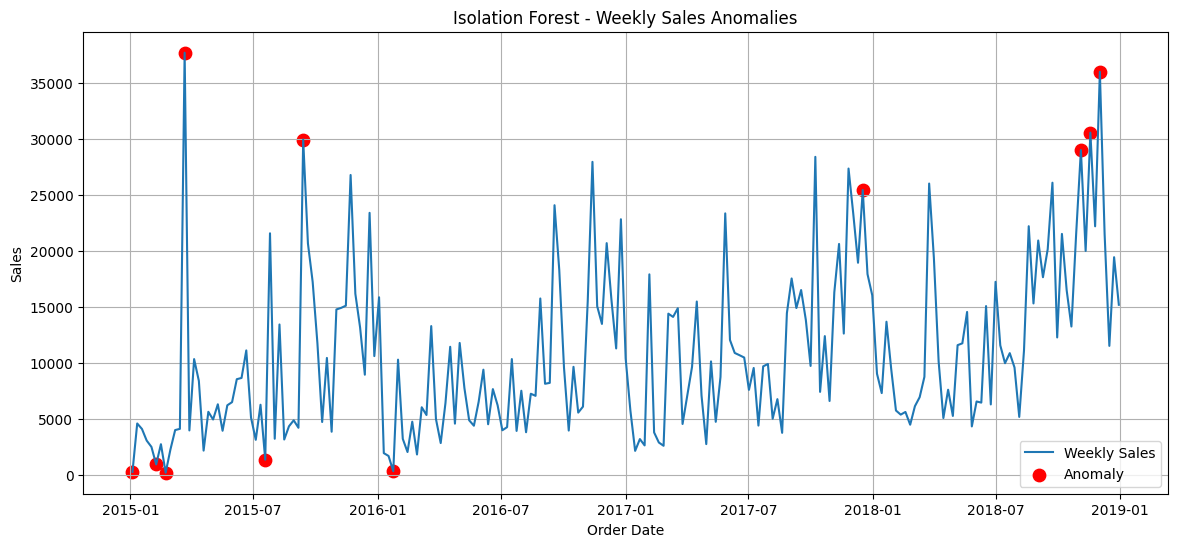

In [121]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# Plot weekly sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

# Plot anomaly points
anomalies = weekly_sales[weekly_sales["IF_Anomaly"] == -1]

plt.scatter(
    anomalies["Order Date"],
    anomalies["Sales"],
    color="red",
    s=80,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

### Using rolling mean 

In [122]:
weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .mean()
    .shift(1)
)

In [123]:
weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(window=4)
    .std()
    .shift(1)
)

In [124]:
weekly_sales["Z_Score"] = (
    (weekly_sales["Sales"] - weekly_sales["Rolling_Mean"])
    / weekly_sales["Rolling_STD"]
)



In [125]:
weekly_sales["Z_Anomaly"] = weekly_sales["Z_Score"].abs() > 2

In [126]:
weekly_sales["Z_Anomaly"].value_counts()


Z_Anomaly
False    169
True      40
Name: count, dtype: int64

In [127]:
weekly_sales[weekly_sales["Z_Anomaly"]]

,Order Date,Sales,IF_Anomaly,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
5,2015-02-08,968.5340,-1,3592.524750,953.362968,-2.752352,True
7,2015-02-22,224.9120,-1,2340.011500,943.108457,-2.242690,True
9,2015-03-08,4030.7280,1,1563.535750,1173.495162,2.102431,True
11,2015-03-22,37703.6650,-1,2671.221250,1837.972754,19.060372,True
22,2015-06-07,8569.9480,1,5766.387750,1204.728869,2.327130,True
24,2015-06-21,11139.4446,1,7504.611750,1301.478386,2.792849,True
26,2015-07-05,3158.4000,1,8384.157900,2464.041386,-2.120808,True
29,2015-07-26,21590.0800,1,3995.168000,2167.025645,8.119383,True
36,2015-09-13,29959.1370,-1,4172.795625,717.144865,35.956949,True
46,2015-11-22,26793.6235,1,12185.782550,5536.913882,2.638264,True


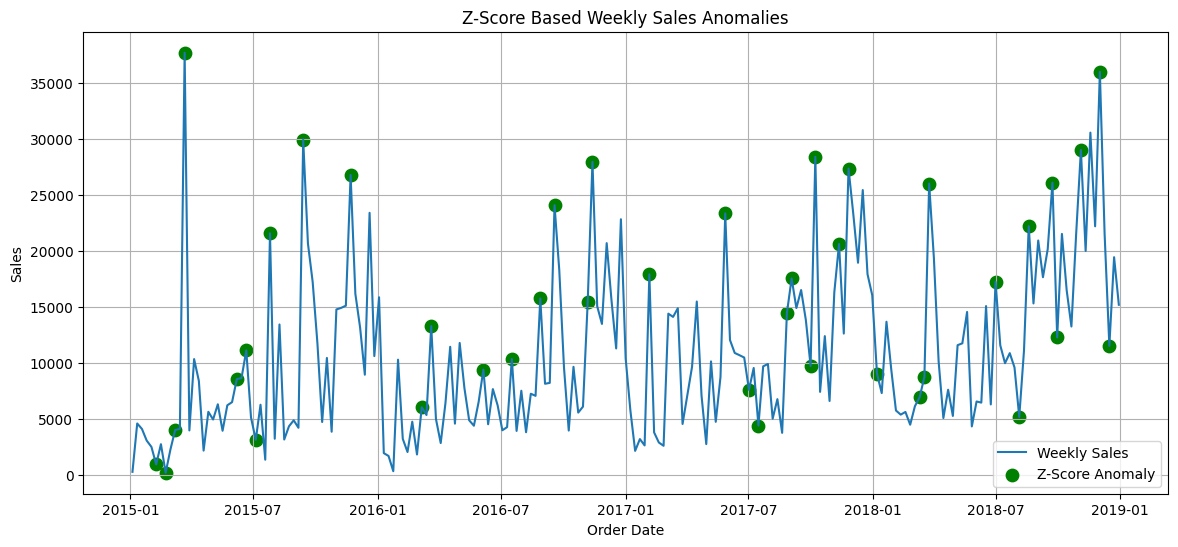

In [128]:
plt.figure(figsize=(14,6))

# Plot weekly sales
plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales"
)

# Plot Z-score anomalies
z_anomalies = weekly_sales[weekly_sales["Z_Anomaly"]]

plt.scatter(
    z_anomalies["Order Date"],
    z_anomalies["Sales"],
    color="green",
    s=80,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Weekly Sales Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
comparison = weekly_sales[
    ["Order Date", "Sales", "IF_Anomaly", "Z_Anomaly"]
]

comparison.head()

In [ ]:
both = weekly_sales[
    (weekly_sales["IF_Anomaly"] == -1) &
    (weekly_sales["Z_Anomaly"])
]

both

In [ ]:
len(both)

#### Isolation Forest

Isolation Forest detected 11 anomalous weeks. It identified both unusually high sales spikes and unusually low sales weeks. Several anomalies occurred during November and December, which likely correspond to holiday shopping and promotional periods. A few anomalies at the beginning of the dataset are likely caused by partial-week data rather than actual business events.

#### Z-Score Method

The rolling Z-score method detected 40 anomalous weeks, considerably more than Isolation Forest. Since it compares each week with only the previous four weeks, it is more sensitive to short-term fluctuations and identifies many temporary spikes and drops.

### Comparison

The two methods agree on several major anomalies, particularly extreme sales spikes. However, Z-score flags many additional observations because it measures short-term deviations, whereas Isolation Forest focuses on globally unusual observations. For business monitoring, Isolation Forest is better suited for identifying only the most significant anomalies, while Z-score is useful for detecting local changes in sales behavior.

# TASK 6

Step 1: Create Product-Level Features
- Total Sales Volume
- Sales Growth Rate
- Sales Volatility
- Average Order Value


In [129]:
total_sales = (
    df.groupby("Sub-Category")["Sales"]
      .sum()
      .rename("Total_Sales")
)

In [130]:
total_sales.head()

Sub-Category
Accessories    164186.7000
Appliances     104618.4030
Art             26705.4100
Binders        200028.7850
Bookcases      113813.1987
Name: Total_Sales, dtype: float64

In [131]:
avg_order = (
    df.groupby("Sub-Category")["Sales"]
      .mean()
      .rename("Avg_Order_Value")
)

In [132]:
avg_order.head()

Sub-Category
Accessories    217.178175
Appliances     227.926804
Art             34.019631
Binders        134.067550
Bookcases      503.598224
Name: Avg_Order_Value, dtype: float64

In [133]:
monthly_sales = (
    df.groupby(
        [pd.Grouper(key="Order Date", freq="ME"), "Sub-Category"]
    )["Sales"]
    .sum()
    .reset_index()
)


In [134]:
volatility = (
    monthly_sales.groupby("Sub-Category")["Sales"]
    .std()
    .rename("Sales_Volatility")
)

In [135]:
yearly_sales = (
    df.groupby(["Year", "Sub-Category"])["Sales"]
    .sum()
    .reset_index()
)

In [136]:
growth = (
    yearly_sales.groupby("Sub-Category")["Sales"]
    .apply(lambda x: (x.iloc[-1] - x.iloc[0]) / x.iloc[0])
    .rename("Growth_Rate")
)

In [137]:
volatility.head()

Sub-Category
Accessories    2579.994809
Appliances     1821.621539
Art             330.488343
Binders        3848.223648
Bookcases      2220.405080
Name: Sales_Volatility, dtype: float64

In [138]:
growth.head()

Sub-Category
Accessories    1.450560
Appliances     1.652429
Art            0.496495
Binders        0.657786
Bookcases      0.498466
Name: Growth_Rate, dtype: float64

In [139]:
cluster_data = pd.concat(
    [total_sales, avg_order, volatility, growth],
    axis=1
)

In [140]:
cluster_data.head()

,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,2579.994809,1.450560
Appliances,104618.4030,227.926804,1821.621539,1.652429
Art,26705.4100,34.019631,330.488343,0.496495
Binders,200028.7850,134.067550,3848.223648,0.657786
Bookcases,113813.1987,503.598224,2220.405080,0.498466


In [141]:
cluster_data.isna().sum()

Total_Sales         0
Avg_Order_Value     0
Sales_Volatility    0
Growth_Rate         0
dtype: int64

In [142]:
from sklearn.preprocessing import StandardScaler

In [143]:
scaler = StandardScaler()

In [144]:
scaled_data = scaler.fit_transform(cluster_data)

In [145]:
from sklearn.cluster import KMeans

In [146]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(scaled_data)

    wcss.append(kmeans.inertia_)

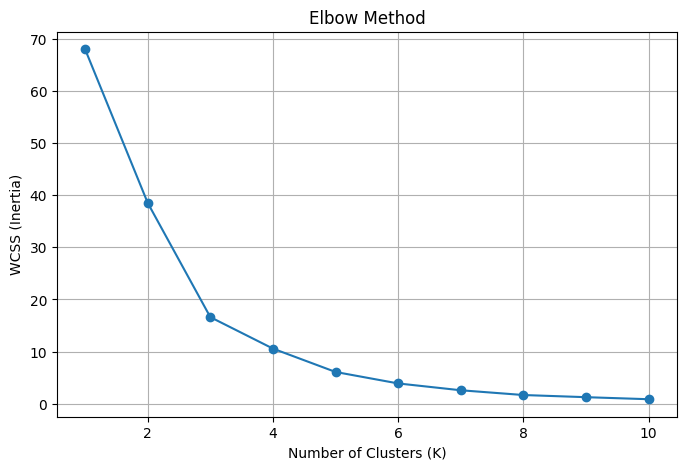

In [147]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")
plt.title("Elbow Method")

plt.grid(True)

plt.show()

The Elbow Method indicates that K = 3 is an appropriate choice because the WCSS decreases sharply until three clusters and then begins to flatten. Beyond K = 3, adding more clusters provides only marginal improvement while increasing model complexity.

In [148]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

cluster_labels = kmeans.fit_predict(scaled_data)

In [149]:
cluster_data["Cluster"] = cluster_labels

In [157]:
cluster_results = cluster_data.reset_index()

cluster_results.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster
0,Accessories,164186.7000,217.178175,2579.994809,1.450560,1
1,Appliances,104618.4030,227.926804,1821.621539,1.652429,1
2,Art,26705.4100,34.019631,330.488343,0.496495,1
3,Binders,200028.7850,134.067550,3848.223648,0.657786,2
4,Bookcases,113813.1987,503.598224,2220.405080,0.498466,1


In [158]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [159]:
features = [
    "Total_Sales",
    "Avg_Order_Value",
    "Sales_Volatility",
    "Growth_Rate"
]


scaled_features = StandardScaler().fit_transform(
    cluster_results[features]
)


pca = PCA(
    n_components=2
)


pca_values = pca.fit_transform(
    scaled_features
)


cluster_results["PCA1"] = pca_values[:,0]

cluster_results["PCA2"] = pca_values[:,1]


cluster_results.head()

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster,PCA1,PCA2
0,Accessories,164186.7000,217.178175,2579.994809,1.450560,1,0.200367,0.116729
1,Appliances,104618.4030,227.926804,1821.621539,1.652429,1,-0.264248,0.707660
2,Art,26705.4100,34.019631,330.488343,0.496495,1,-1.676784,0.535820
3,Binders,200028.7850,134.067550,3848.223648,0.657786,2,0.484161,-0.805597
4,Bookcases,113813.1987,503.598224,2220.405080,0.498466,1,-0.176589,0.003166


In [160]:
cluster_names = {
    0:"Premium High-Value Products",
    1:"Low-Medium Volume Stable Demand",
    2:"High Volume Core Products"
}


cluster_results["Cluster_Name"] = (
    cluster_results["Cluster"]
    .map(cluster_names)
)


cluster_results

,Sub-Category,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster,PCA1,PCA2,Cluster_Name
0,Accessories,164186.7000,217.178175,2579.994809,1.450560,1,0.200367,0.116729,Low-Medium Volume Stable Demand
1,Appliances,104618.4030,227.926804,1821.621539,1.652429,1,-0.264248,0.707660,Low-Medium Volume Stable Demand
2,Art,26705.4100,34.019631,330.488343,0.496495,1,-1.676784,0.535820,Low-Medium Volume Stable Demand
3,Binders,200028.7850,134.067550,3848.223648,0.657786,2,0.484161,-0.805597,High Volume Core Products
4,Bookcases,113813.1987,503.598224,2220.405080,0.498466,1,-0.176589,0.003166,Low-Medium Volume Stable Demand
5,Chairs,322822.7310,531.833165,4407.232960,0.209547,2,1.479554,-1.711393,High Volume Core Products
6,Copiers,146248.0940,2215.880212,5500.774391,4.797295,0,4.046026,2.979941,Premium High-Value Products
7,Envelopes,16128.0460,65.032444,228.218688,-0.121213,1,-1.920711,0.234844,Low-Medium Volume Stable Demand
8,Fasteners,3001.9600,14.027850,48.742229,0.304684,1,-1.960973,0.583155,Low-Medium Volume Stable Demand
9,Furnishings,89212.0180,95.823865,1360.017867,1.068250,1,-0.798984,0.421706,Low-Medium Volume Stable Demand


In [161]:
cluster_results.to_csv(
    "cluster_results.csv",
    index=False
)

In [150]:
cluster_data

,Total_Sales,Avg_Order_Value,Sales_Volatility,Growth_Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,2579.994809,1.450560,1
Appliances,104618.4030,227.926804,1821.621539,1.652429,1
Art,26705.4100,34.019631,330.488343,0.496495,1
Binders,200028.7850,134.067550,3848.223648,0.657786,2
Bookcases,113813.1987,503.598224,2220.405080,0.498466,1
Chairs,322822.7310,531.833165,4407.232960,0.209547,2
Copiers,146248.0940,2215.880212,5500.774391,4.797295,0
Envelopes,16128.0460,65.032444,228.218688,-0.121213,1
Fasteners,3001.9600,14.027850,48.742229,0.304684,1


In [151]:
for cluster in sorted(cluster_data["Cluster"].unique()):
    print(f"\nCluster {cluster}")
    print(cluster_data[cluster_data["Cluster"] == cluster].index.tolist())


Cluster 0
['Copiers']

Cluster 1
['Accessories', 'Appliances', 'Art', 'Bookcases', 'Envelopes', 'Fasteners', 'Furnishings', 'Labels', 'Paper', 'Supplies']

Cluster 2
['Binders', 'Chairs', 'Machines', 'Phones', 'Storage', 'Tables']


In [152]:
from sklearn.decomposition import PCA

In [153]:
pca = PCA(n_components=2)

pca_data = pca.fit_transform(scaled_data)

In [154]:
pca_df = pd.DataFrame(
    pca_data,
    columns=["PC1", "PC2"]
)

pca_df["Cluster"] = cluster_labels
pca_df["Sub-Category"] = cluster_data.index

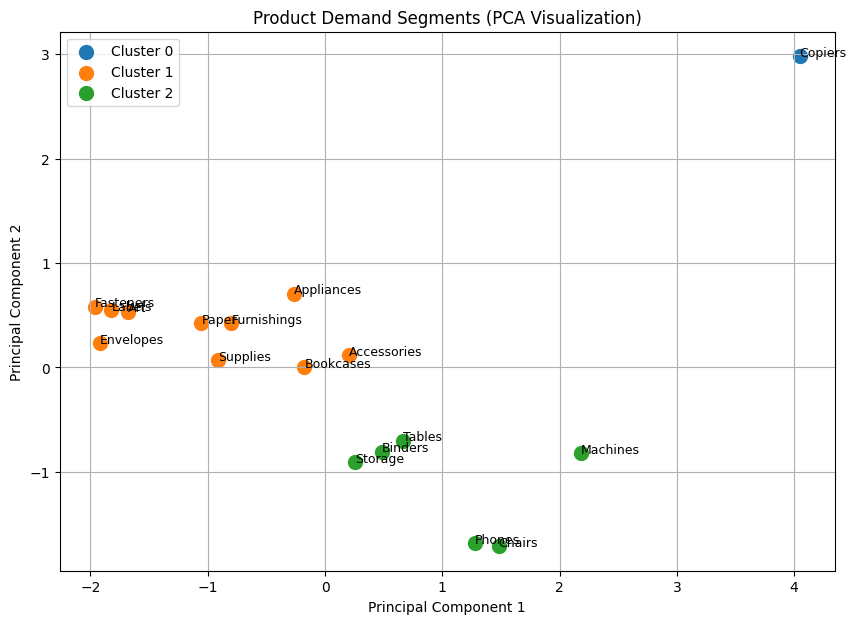

In [155]:
plt.figure(figsize=(10,7))

for cluster in sorted(pca_df["Cluster"].unique()):

    subset = pca_df[pca_df["Cluster"] == cluster]

    plt.scatter(
        subset["PC1"],
        subset["PC2"],
        s=100,
        label=f"Cluster {cluster}"
    )

    for _, row in subset.iterrows():
        plt.text(
            row["PC1"],
            row["PC2"],
            row["Sub-Category"],
            fontsize=9
        )

plt.title("Product Demand Segments (PCA Visualization)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend()
plt.grid(True)

plt.show()

Cluster 0 — Premium High-Value Products
- Maintain limited but carefully managed inventory.
- Closely monitor demand due to high volatility.
- Prioritize supplier relationships because stockouts could be costly.

Cluster 1 — Low-to-Medium Volume Stable Demand
- Use conservative inventory levels.
- Replenish periodically rather than frequently.
- Focus on operational efficiency rather than aggressive stocking.

Cluster 2 — High Volume Core Products
- Maintain high inventory availability.
- Prioritize these products in forecasting and inventory planning.
- Monitor demand continuously to avoid stockouts, as these products contribute significantly to revenue.

# TASK 7

In [71]:
# Save processed dataset
df.to_csv("train_processed.csv", index=False)

print("train_processed.csv saved successfully!")

train_processed.csv saved successfully!


In [72]:
# Save monthly sales
monthly_sales.to_csv("monthly_sales.csv", index=False)

print("monthly_sales.csv saved successfully!")

monthly_sales.csv saved successfully!


In [73]:
# Save weekly anomaly dataset
weekly_sales.to_csv("weekly_sales.csv", index=False)

print("weekly_sales.csv saved successfully!")

weekly_sales.csv saved successfully!


In [75]:
# # Save clustering results
# cluster_data.to_csv("cluster_data.csv")

# print("cluster_data.csv saved successfully!")

In [54]:
%who

SARIMAX	 adfuller	 category_sales	 comparison	 confidence_intervals	 daily_sales	 decomposition	 df	 fig	 
forecast	 future_forecast	 get_season	 key	 mae	 mape	 mean_absolute_error	 mean_squared_error	 monthly_sales	 
monthly_series	 monthly_trend	 np	 pd	 plt	 region	 region_data	 region_year_sales	 result	 
rmse	 sarima_model	 sarima_result	 seasonal_decompose	 shipping_by_region	 sns	 test	 train	 value	 
weekly_sales	 year	 year_data	 


In [63]:
region_sales = (
    df.groupby("Region")["Sales"]
      .sum()
      .reset_index()
)

In [101]:
forecast.head()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2015-01-31,33505.686141,4690.320931,23312.306181,33505.686141,33505.686141,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,14300.788630
1,2015-02-28,33906.289832,-6963.036334,11120.454355,33906.289832,33906.289832,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,2292.490775
2,2015-03-31,34349.815347,42597.831942,61018.833861,34349.815347,34349.815347,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,52016.921025
3,2015-04-30,34779.033587,11721.927909,30435.566773,34779.033587,34779.033587,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,-13655.620453,0.0,0.0,0.0,21123.413134
4,2015-05-31,35222.559103,13784.187304,32071.251176,35222.559103,35222.559103,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,-12496.061322,0.0,0.0,0.0,22726.497781


In [102]:
forecast_export = forecast[
    ["ds", "yhat", "yhat_lower", "yhat_upper"]
].copy()

forecast_export.columns = [
    "Order Date",
    "Forecast",
    "Lower",
    "Upper"
]

forecast_export.to_csv(
    "forecast.csv",
    index=False
)

print("forecast.csv saved successfully!")

forecast.csv saved successfully!


In [103]:
comparison_prophet.to_csv(
    "comparison_prophet.csv",
    index=False
)

print("comparison_prophet.csv saved!")

comparison_prophet.csv saved!


In [106]:
metrics = pd.DataFrame({
    "Metric": ["MAE", "RMSE", "MAPE"],
    "Value": [mae_prophet, rmse_prophet, mape_prophet]
})

metrics.to_csv(
    "metrics.csv",
    index=False
)

print(metrics)

  Metric         Value
0    MAE  13434.279047
1   RMSE  14049.751393
2   MAPE     14.642329


In [107]:
print(comparison_prophet.columns.tolist())

['ds', 'Actual', 'Predicted']
